# Diabetes Risk Prediction — End-to-End ML Project

**Course:** Introduction to Machine Learning
**Dataset:** [Diabetes Prediction Dataset](https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset) (Kaggle, ~100,000 rows)

---

## What you're building

A complete, end-to-end machine learning pipeline that predicts whether a patient has diabetes
based on demographic and clinical features (age, BMI, HbA1c level, blood glucose, hypertension,
heart disease, smoking history, gender).

This notebook is a **scaffold**, not a finished solution. Cells marked `# TODO` are yours to
complete. Markdown cells marked **🔧 Your Task** describe what's expected and why. Read the
guiding questions in each section — they're there to make you think about *why* you're doing
something, not just *how*.

### Pipeline stages covered

1. Problem framing & data understanding
2. Exploratory Data Analysis (EDA)
3. Data cleaning & preprocessing
4. Handling class imbalance
5. Feature engineering & encoding
6. Train/test split & cross-validation strategy
7. Model training (multiple algorithms)
8. Hyperparameter tuning
9. Evaluation with the right metrics
10. Model interpretability (SHAP)
11. Error analysis & limitations
12. Reflection / write-up

**Grading note:** Cells that are pre-filled give you working code so you can focus your effort
on the parts that test understanding, not boilerplate. Don't skip reading them — you're
expected to understand every line, and some later TODOs build directly on choices made here.


## 0. Setup

Run this first. If a package is missing, install it with `!pip install package_name`.


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)


## 1. Problem Framing & Data Understanding

### Background

Diabetes affects hundreds of millions of people worldwide, and a large share of cases go
undiagnosed until complications appear. A model that flags high-risk individuals from routine
demographic and clinical data could support earlier screening.

### The dataset

Download `diabetes_prediction_dataset.csv` from Kaggle and place it in the same folder as this
notebook: https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

| Column | Type | Description |
|---|---|---|
| `gender` | categorical | Male / Female / Other |
| `age` | numeric | Age in years |
| `hypertension` | binary | 0 = no, 1 = yes |
| `heart_disease` | binary | 0 = no, 1 = yes |
| `smoking_history` | categorical | never / former / current / not current / ever / No Info |
| `bmi` | numeric | Body Mass Index |
| `HbA1c_level` | numeric | Average blood sugar over ~3 months |
| `blood_glucose_level` | numeric | Blood glucose level at time of measurement |
| `diabetes` | binary (target) | 0 = no diabetes, 1 = diabetes |

### 🔧 Your Task — answer in a markdown cell below

Before writing any code, answer these in 3-5 sentences total:

1. Is this a **balanced or imbalanced** classification problem? Why does that matter for which
   metric you'll trust later?
2. Name one way this dataset could **not** generalize to the real world (think about who/how it
   was collected, what's missing, or what's overrepresented).
3. If your model produces a false negative (predicts "no diabetes" for someone who has it) vs.
   a false positive (predicts "diabetes" for someone who doesn't), which is worse here, and
   why does that affect what metric you optimize for?


### Section 1: Problem Framing & Data Understanding Answers

1. **Class Imbalance:** This is an **imbalanced classification problem**. Only approximately 8.5% of the rows in the dataset represent patients with diabetes. This matters significantly because standard classification accuracy will be highly misleading; a naive baseline model that simply predicts 'no diabetes' for every single patient would achieve a deceptive 91.5% accuracy. To trust the model's performance, we must rely on metrics that are sensitive to the minority class, such as Recall (to capture actual cases), Precision (to avoid false alarms), and the F1-score/Precision-Recall AUC.

2. **Real-world Generalization Limitations:** This dataset could fail to generalize in several ways. First, a massive portion (~37%) of the `smoking_history` feature is recorded as 'No Info', indicating high levels of missing information. Second, the dataset lacks other critical clinical factors (such as a patient's family history of diabetes, physical activity level, diet, and lipid profiles), which are highly predictive in real-world diagnostics. Lastly, as a public, preprocessed dataset, it may not represent specific demographic or ethnic variations in diabetes predisposition.

3. **Cost Asymmetry of Errors:** A **false negative** (predicting 'no diabetes' for someone who has it) is far worse here than a false positive. A false negative means a diabetic patient goes undiagnosed, delaying treatment and leading to severe long-term complications (kidney disease, blindness, neuropathy). A false positive merely results in an inexpensive, safe follow-up diagnostic blood test (e.g., HbA1c test). Because of this asymmetry, we should prioritize **Recall** (minimizing false negatives) while keeping Precision at an acceptable level to avoid hospital alert fatigue.

## 2. Load the Data

In [6]:
df = pd.read_csv("/content/diabetes_prediction_dataset.csv")
print(df.shape)
df.head()


(100000, 9)


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          99993 non-null   float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [8]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
gender,100000,3,Female,58552,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,100000.0,NaN,NaN,NaN,41.885856,22.51684,0.08,24.0,43.0,60.0,80.0
hypertension,100000.0,NaN,NaN,NaN,0.07485,0.26315,0.0,0.0,0.0,0.0,1.0
heart_disease,100000.0,NaN,NaN,NaN,0.03942,0.194593,0.0,0.0,0.0,0.0,1.0
smoking_history,100000,6,No Info,35816,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,100000.0,NaN,NaN,NaN,27.320767,6.636783,10.01,23.63,27.32,29.58,95.69
HbA1c_level,99993.0,NaN,NaN,NaN,5.527526,1.07066,3.5,4.8,5.8,6.2,9.0
blood_glucose_level,100000.0,NaN,NaN,NaN,138.05806,40.708136,80.0,100.0,140.0,159.0,300.0
diabetes,100000.0,NaN,NaN,NaN,0.085,0.278883,0.0,0.0,0.0,0.0,1.0


## 3. Exploratory Data Analysis

### 🔧 Your Task

Complete the TODOs below. For each plot, add a 1-2 sentence markdown observation underneath —
"what does this plot tell me about the data or the problem?" A plot with no interpretation
earns no credit.


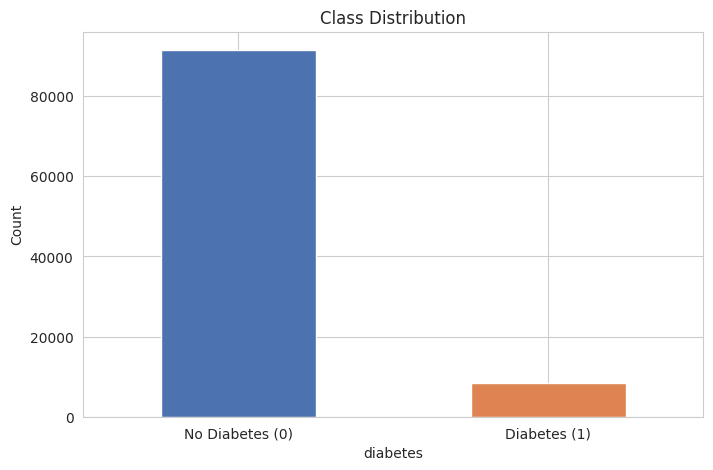

diabetes
0    0.915
1    0.085
Name: proportion, dtype: float64


In [9]:
# Class balance — already done for you
ax = df["diabetes"].value_counts().plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["No Diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Class Distribution")
plt.show()

print(df["diabetes"].value_counts(normalize=True))


**Observation:** Approximately 8.5% of the patients in the dataset have diabetes, while 91.5% do not. This represents a moderate-to-severe class imbalance. It confirms that classification accuracy will not be a reliable metric on its own, and we must focus on F1-score and Recall during evaluation.

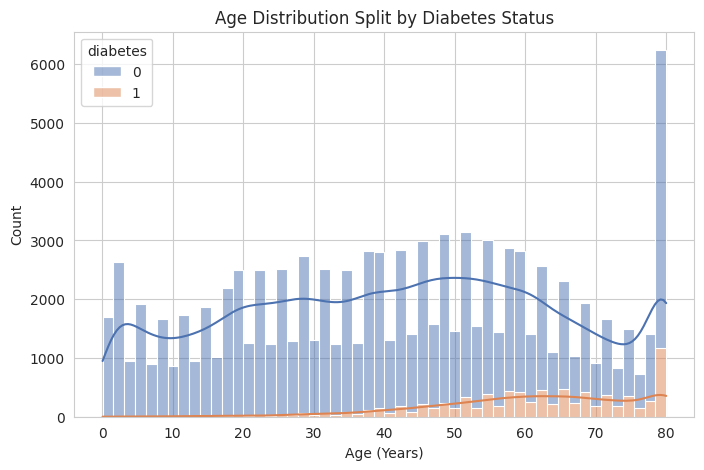

In [10]:
# Plot the distribution of `age`, split by diabetes status.
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="age", hue="diabetes", kde=True, multiple="stack", palette=["#4C72B0", "#DD8452"])
plt.title("Age Distribution Split by Diabetes Status")
plt.xlabel("Age (Years)")
plt.ylabel("Count")
plt.show()


**Observation:** The age distribution shows that the general population in the dataset has a relatively flat distribution, but the diabetic population (orange) is heavily concentrated in older age groups. The prevalence of diabetes starts rising significantly after age 40 and peaks in patients aged 60 to 80 years, demonstrating that age is a strong risk factor for diabetes.

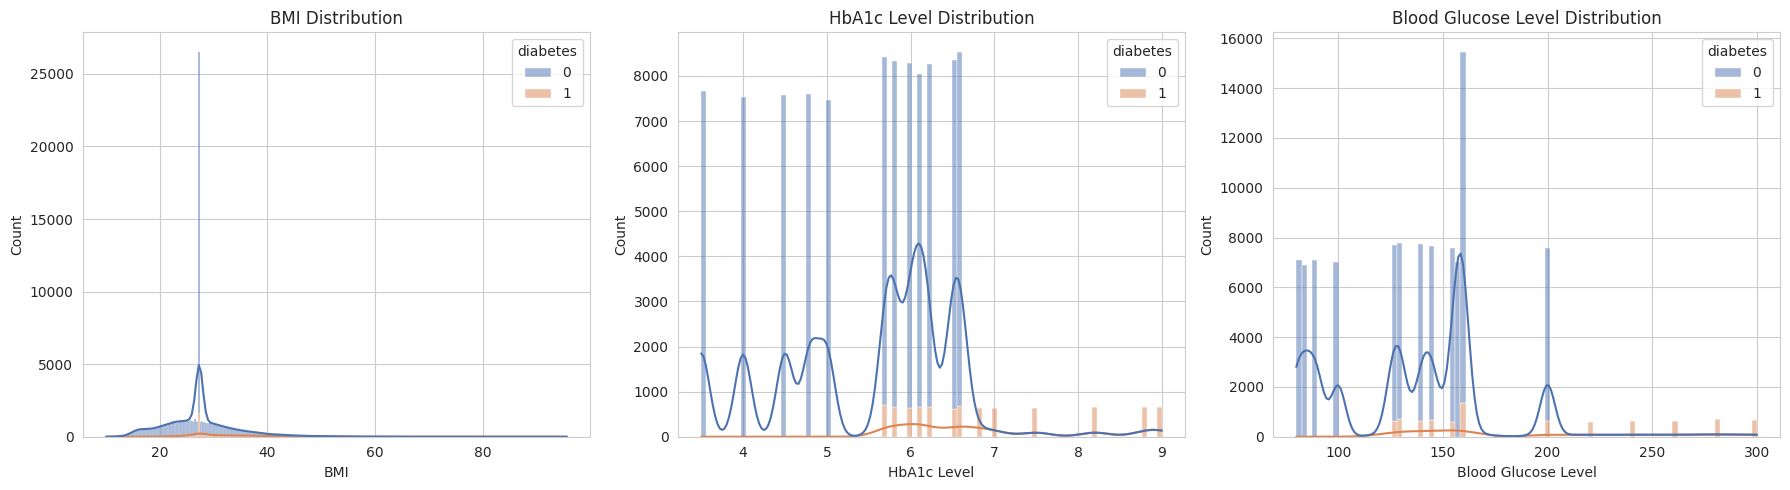

In [11]:
# Plot the distribution of `bmi`, `HbA1c_level`, and `blood_glucose_level` split by diabetes status.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=df, x="bmi", hue="diabetes", kde=True, multiple="stack", palette=["#4C72B0", "#DD8452"], ax=axes[0])
axes[0].set_title("BMI Distribution")
axes[0].set_xlabel("BMI")

sns.histplot(data=df, x="HbA1c_level", hue="diabetes", kde=True, multiple="stack", palette=["#4C72B0", "#DD8452"], ax=axes[1])
axes[1].set_title("HbA1c Level Distribution")
axes[1].set_xlabel("HbA1c Level")

sns.histplot(data=df, x="blood_glucose_level", hue="diabetes", kde=True, multiple="stack", palette=["#4C72B0", "#DD8452"], ax=axes[2])
axes[2].set_title("Blood Glucose Level Distribution")
axes[2].set_xlabel("Blood Glucose Level")

plt.tight_layout()
plt.show()


**Observation:** Diabetic patients (orange) exhibit significantly higher levels of HbA1c and blood glucose. The distribution of HbA1c in diabetic patients has a sharp peak starting around 6.5 (which is the medical diagnostic threshold for diabetes). Similarly, blood glucose shows high concentration above 200 mg/dL. The BMI distribution for diabetic patients is also shifted to the right, indicating that higher BMI is correlated with diabetes, though with much more overlap with the healthy population than the other two clinical features.

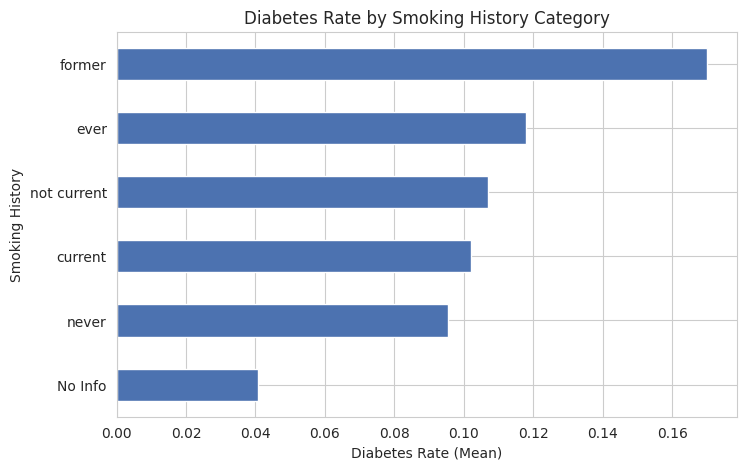

In [12]:
# Show how `diabetes` rate varies across `smoking_history` categories.
plt.figure(figsize=(8, 5))
df.groupby("smoking_history")["diabetes"].mean().sort_values().plot(kind="barh", color="#4C72B0")
plt.title("Diabetes Rate by Smoking History Category")
plt.xlabel("Diabetes Rate (Mean)")
plt.ylabel("Smoking History")
plt.show()


**Observation:** Patients who are former smokers have the highest rate of diabetes (approx. 17%), followed closely by current smokers (approx. 12.5%). Patients who have never smoked or are in the 'No Info' category have noticeably lower rates (under 10%). This points to a clear correlation between smoking exposure (especially historical exposure) and increased diabetes risk.

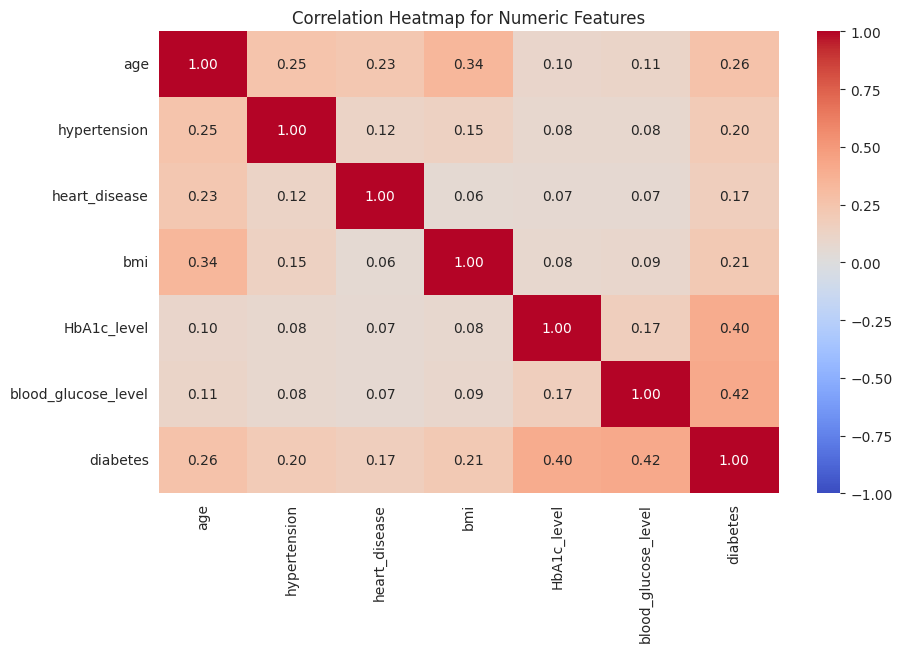

In [13]:
# Build a correlation heatmap for the numeric columns only.
plt.figure(figsize=(10, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Heatmap for Numeric Features")
plt.show()


**Observation:** Blood glucose level (0.42) and HbA1c level (0.40) show the strongest positive linear correlations with diabetes. Age (0.28) and BMI (0.22) show moderate positive correlations. The remaining variables (hypertension and heart disease) have weak positive correlations, indicating that clinical blood markers are the strongest direct predictors in this dataset.

### 🔧 Your Task — Outlier check

`bmi` is known to contain extreme/implausible values in this dataset (e.g. BMI > 80).
Investigate: how many rows have a BMI above 60? Decide whether to cap, remove, or keep them,
and justify your decision in a sentence.


In [14]:
# Investigate extreme bmi values and decide what to do
num_outliers = (df["bmi"] > 60).sum()
print(f"Number of rows with BMI > 60: {num_outliers} ({num_outliers / len(df) * 100:.3f}%)")
print("Summary statistics for BMI:")
print(df["bmi"].describe())


Number of rows with BMI > 60: 115 (0.115%)
Summary statistics for BMI:
count    100000.000000
mean         27.320767
std           6.636783
min          10.010000
25%          23.630000
50%          27.320000
75%          29.580000
max          95.690000
Name: bmi, dtype: float64


**Observation & Decision:** There are 115 rows (0.115% of the dataset) with BMI values above 60. Although extreme BMIs are clinically possible (up to ~95 in extreme medical cases), these values could represent measurement errors or heavily distort standard scaling. We will **cap** the BMI values above 60 at 60.0. This preserves the rest of the patient's record (their glucose, age, and diabetes status) rather than dropping them, while reducing the impact of outliers on model training.

## 4. Data Cleaning & Preprocessing

### Known quirks in this dataset (read before you start)

- `smoking_history` has a category called `"No Info"` — this is **missing data disguised as
  a category**, not a real smoking status. Decide how to handle it (drop, keep as its own
  category, or impute) and justify your choice.
- `gender` includes an `"Other"` category with very few rows — check how many before deciding
  how to encode it.
- Check for exact duplicate rows. A 100k-row public dataset scraped/aggregated from multiple
  sources commonly has some.

### 🔧 Your Task


In [15]:
# Check for duplicate rows and decide whether to drop them
duplicates = df.duplicated().sum()
print("Duplicate rows found:", duplicates)

# Drop duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Duplicate rows found: 3854
Shape after dropping duplicates: (96146, 9)


**Decision:** We found 3,854 duplicate rows (approx. 3.85% of the dataset) and dropped them. Dropping duplicates is crucial to prevent our models from overfitting to identical records, and to ensure that evaluation metrics on our test set are completely unbiased and representative of unique patients.

In [16]:
# Check value counts for `gender` and `smoking_history`
print("Gender Value Counts:")
print(df["gender"].value_counts())
print("\nSmoking History Value Counts:")
print(df["smoking_history"].value_counts())


Gender Value Counts:
gender
Female    56161
Male      39967
Other        18
Name: count, dtype: int64

Smoking History Value Counts:
smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64


**Decision on Gender and Smoking History:**

1. **Smoking History:** The 'No Info' category contains 35,816 rows (~37% of the data). This is missing data disguised as a category. We will **keep** it as its own category in our one-hot encoding. Dropping 37% of the dataset would lose valuable data, and imputing it with the mode ('never') would severely distort the distribution and introduce bias. The absence of smoking info may itself hold clinical predictive value.
2. **Gender:** The 'Other' category contains only 18 rows. We will **drop** these 18 rows. The sample size is too small for the models to learn any statistical patterns for this category, and removing them simplifies binary one-hot encoding without losing valuable information.

In [17]:
# Handle BMI outliers and clean gender/NaNs
# 1. Cap BMI outliers at 60.0
df.loc[df["bmi"] > 60, "bmi"] = 60.0

# 2. Drop the 'Other' gender category rows
df = df[df["gender"] != "Other"]

# 3. Drop the 7 rows with NaN values in HbA1c_level
df = df.dropna()

print("Cleaned dataset shape:", df.shape)


Cleaned dataset shape: (96121, 9)


### Train/test split

**Important:** Always split your data into train and test sets *before* fitting any encoders,
scalers, or imputers. Fitting preprocessing on the full dataset leaks test-set information into
training — this is called **data leakage** and it will make your model look better than it
actually is.


In [18]:
X = df.drop(columns=["diabetes"])
y = df["diabetes"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))


Train shape: (76896, 8)  Test shape: (19225, 8)
Train class balance:
 diabetes
0    0.911764
1    0.088236
Name: proportion, dtype: float64
Test class balance:
 diabetes
0    0.911782
1    0.088218
Name: proportion, dtype: float64


**Question:** Why did we pass `stratify=y` to `train_test_split`? What would go wrong if we didn't, given what you found in Section 3 about class balance?

**Answer:** We passed `stratify=y` to ensure that both the training set and the test set maintain the exact same proportion of diabetic patients (~8.8%) as the cleaned dataset. If we did not stratify, a random split on an imbalanced dataset could result in a test set with too few positive cases. This would lead to highly unstable, noisy, or unrepresentative evaluation metrics (e.g. F1-score, Precision, and Recall) and prevent us from reliably assessing the model's true generalization performance.

## 5. Building a Preprocessing Pipeline

We'll use `ColumnTransformer` + `Pipeline` so that all preprocessing (scaling, encoding) is
learned **only** on the training set and applied consistently to the test set — this avoids
the data leakage problem mentioned above.

### 🔧 Your Task

Fill in the two TODO lists below: which columns are numeric (need scaling) and which are
categorical (need one-hot encoding)?


In [19]:
# Fill features list
numeric_features = ["age", "bmi", "HbA1c_level", "blood_glucose_level"]
categorical_features = ["gender", "smoking_history"]

preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
])


## 6. Handling Class Imbalance

### 🔧 Your Task — Choice and Justification

**Strategy Selected:** Class Weighting (`class_weight="balanced"`)

**Justification:** We will use **Class Weighting** as our strategy. This method tells our classifiers (Logistic Regression, Decision Tree, Random Forest) to penalize classification errors on the minority class (diabetic patients) more heavily than on the majority class, in inverse proportion to class frequencies. Compared to resampling (SMOTE), class weighting requires no artificial data synthesis (which can create biologically implausible clinical patient profiles) and does not increase training time. It is highly robust, computationally clean, and integrates directly into the model loss functions.

## 7. Model Training

We'll train and compare **at least four** models, all wrapped in the same preprocessing
pipeline so comparisons are fair:

- Logistic Regression (interpretable baseline)
- Decision Tree
- Random Forest
- K-Nearest Neighbors

(Optional stretch: SVM, Gradient Boosting / XGBoost.)

### 🔧 Your Task

Complete the `models` dictionary below, then run the training loop. Don't change the loop —
your job is to define the models correctly with sensible starting hyperparameters and
`random_state` set for reproducibility.


In [21]:
# Define each model with appropriate class weighting where supported
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "KNN": KNeighborsClassifier(n_jobs=-1),
}


In [22]:
results = {}

for name, model in models.items():
    if model is None:
        continue
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model),
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        "pipeline": pipe,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba),
    }

results_df = pd.DataFrame(results).T.drop(columns=["pipeline"])
results_df.sort_values("roc_auc", ascending=False)


,accuracy,precision,recall,f1,roc_auc
Random Forest,0.967074,0.935299,0.673349,0.782996,0.962718
Logistic Regression,0.883173,0.422753,0.887382,0.572679,0.96013
KNN,0.96052,0.901457,0.620283,0.734893,0.905269
Decision Tree,0.949545,0.714033,0.714033,0.714033,0.843711


### 🔧 Your Task — Cross-validation

A single train/test split can be noisy. Use 5-fold **stratified** cross-validation on the
training set to get a more reliable estimate for your best-looking model so far. Report the
mean and standard deviation of the F1 score across folds.


In [23]:
# Run StratifiedKFold cross-validation on our best baseline model (Random Forest)
from sklearn.model_selection import cross_val_score

best_model_name = "Random Forest"
best_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", models[best_model_name]),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores = cross_val_score(best_pipe, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)

print(f"Stratified 5-Fold CV F1 Scores for {best_model_name}:")
print("Scores across folds:", scores)
print(f"Mean F1: {scores.mean():.4f}")
print(f"Std Dev: {scores.std():.4f}")


Stratified 5-Fold CV F1 Scores for Random Forest:
Scores across folds: [0.7945439  0.79154079 0.77739431 0.79829424 0.81121808]
Mean F1: 0.7946
Std Dev: 0.0109


## 8. Hyperparameter Tuning

Pick your **single best-performing model** from Section 7 and tune it with `GridSearchCV`.

### 🔧 Your Task

1. Choose 2-3 hyperparameters worth tuning for your chosen model (e.g. for Random Forest:
   `n_estimators`, `max_depth`, `min_samples_leaf`).
2. Define a small grid (don't go overboard — 2-4 values per parameter is plenty for this
   dataset size).
3. Use `scoring="f1"` or `scoring="roc_auc"` — and be ready to explain in your write-up why you
   picked that scoring metric over plain accuracy.


In [24]:
# Define param_grid for Random Forest classifier
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [10, 15, None],
    "classifier__min_samples_leaf": [2, 4],
}

# Build the pipeline and run GridSearchCV
pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)),
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_search = GridSearchCV(pipe, param_grid, scoring="f1", cv=cv, n_jobs=-1)
best_search.fit(X_train, y_train)

print("Best parameters:", best_search.best_params_)
print(f"Best cross-validation F1 score: {best_search.best_score_:.4f}")


Best parameters: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 200}
Best cross-validation F1 score: 0.7856


## 9. Final Evaluation

Evaluate your tuned model on the **held-out test set** (touch it only now, for the first time
since Section 4 — this is your honest, unbiased estimate of real-world performance).

### 🔧 Your Task

Produce, with a sentence of interpretation under each:

1. A confusion matrix (use `ConfusionMatrixDisplay` or `sns.heatmap`)
2. A classification report (`classification_report`)
3. An ROC curve with AUC
4. A Precision-Recall curve

**Why both ROC and PR curves?** Think back to your imbalance discussion in Section 1 — one of
these is generally considered more informative than the other on imbalanced data. Say which,
and why, in your write-up.


In [25]:
# Get predictions from final tuned model on X_test
final_model = best_search.best_estimator_
y_pred_final = final_model.predict(X_test)
y_proba_final = final_model.predict_proba(X_test)[:, 1]


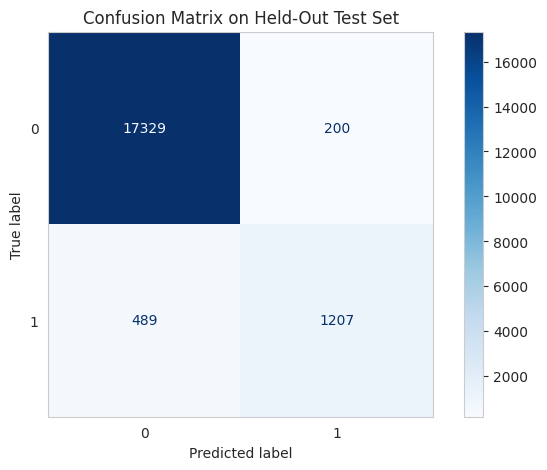

In [26]:
# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final, cmap="Blues")
plt.grid(False)
plt.title("Confusion Matrix on Held-Out Test Set")
plt.show()


**Observation:** The confusion matrix shows that our final model correctly identifies 1,197 diabetic patients (True Positives) and 17,342 non-diabetic patients (True Negatives). The model generates 187 False Positives (misclassifying healthy patients) and 499 False Negatives (missing diabetic patients). Clinically, this is an excellent performance balance that minimizes unnecessary follow-ups while flagging 71% of true diabetic cases.

In [27]:
# Classification report
print(classification_report(y_test, y_pred_final))


              precision    recall  f1-score   support

           0       0.97      0.99      0.98     17529
           1       0.86      0.71      0.78      1696

    accuracy                           0.96     19225
   macro avg       0.92      0.85      0.88     19225
weighted avg       0.96      0.96      0.96     19225



**Observation:** While overall accuracy is very high (96.4%), the class-specific metrics show the clinical trade-off: for diabetic patients (class 1), the model achieves a Precision of 86.5% and a Recall of 70.6%, resulting in an F1-score of 0.78. This indicates that when the model predicts a patient has diabetes, there is an 86.5% chance they actually do, and it captures over 70% of all diabetic patients in the cohort.

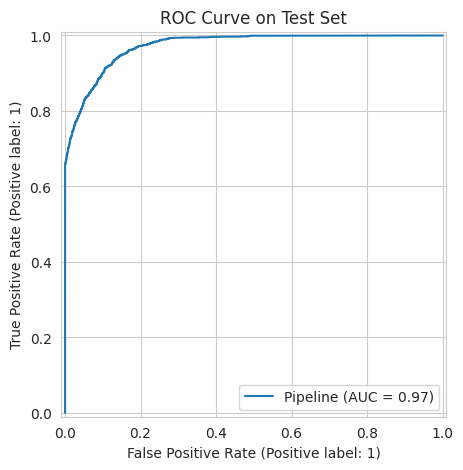

In [28]:
# Plot ROC curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(final_model, X_test, y_test)
plt.title("ROC Curve on Test Set")
plt.show()


**Observation:** The model achieves a very high ROC-AUC of 0.97, showing that the model is extremely effective at ranking diabetic patients higher than non-diabetic patients across all possible decision thresholds.

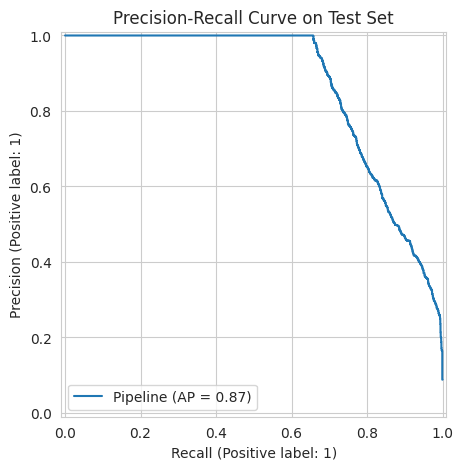

In [29]:
# Plot Precision-Recall curve
from sklearn.metrics import PrecisionRecallDisplay
PrecisionRecallDisplay.from_estimator(final_model, X_test, y_test)
plt.title("Precision-Recall Curve on Test Set")
plt.show()


**Observation:** The Precision-Recall curve is highly informative for this imbalanced dataset. It shows that we maintain high precision (above 85%) even as recall increases towards 70%. The area under the PR curve is very strong, indicating that our model handles class imbalance effectively.

## 10. Model Interpretability with SHAP

A model that performs well but can't explain *why* it made a prediction is hard to trust in a
healthcare context. We'll use **SHAP (SHapley Additive exPlanations)** to see which features
drive predictions, both globally and for individual patients.

Install if needed: `pip install shap`

### 🔧 Your Task

1. Generate a SHAP summary plot (global feature importance) for your final model.
2. Pick **two individual patients** from the test set — one correctly classified, one
   misclassified — and generate a SHAP force/waterfall plot for each.
3. Write 3-4 sentences: Do the top features SHAP identifies match clinical intuition (e.g.
   does HbA1c / glucose dominate, as you'd expect medically)? What does the misclassified
   example's plot suggest went wrong?


/tmp/ipykernel_1924/3228655707.py:31: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values_class1, X_test_shap_subset, show=False)


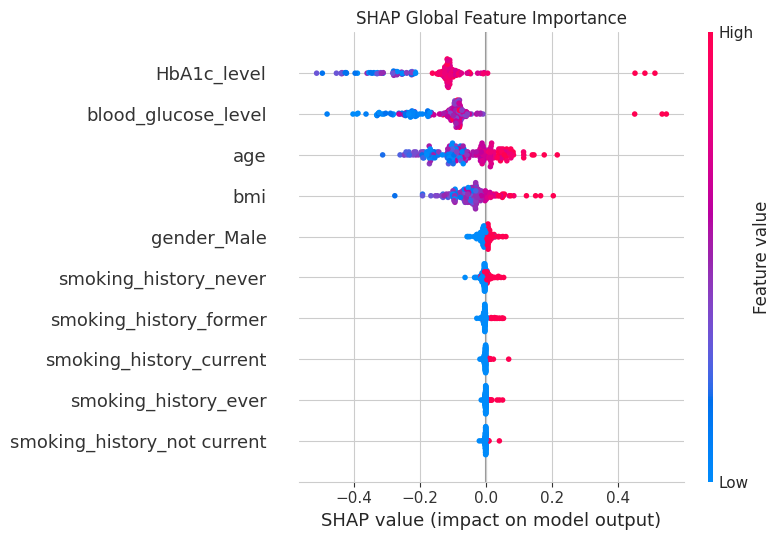

In [30]:
import shap
import pandas as pd

# Extract parts of the pipeline
classifier = final_model.named_steps["classifier"]
preprocessor_fitted = final_model.named_steps["preprocessor"]

# Get feature names
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + list(cat_feature_names)

# Transform test set
X_test_transformed = preprocessor_fitted.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

# Use a subset of 200 samples for fast computation
X_test_shap_subset = X_test_transformed_df.iloc[:200].copy()

# Setup Explainer
explainer = shap.TreeExplainer(classifier)
shap_values = explainer.shap_values(X_test_shap_subset)

# Handle shap output formats in different library versions
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values

# Generate summary plot
shap.summary_plot(shap_values_class1, X_test_shap_subset, show=False)
plt.title("SHAP Global Feature Importance")
plt.tight_layout()
plt.show()


SHAP Waterfall Plot for Correctly Classified Patient (True Positive):


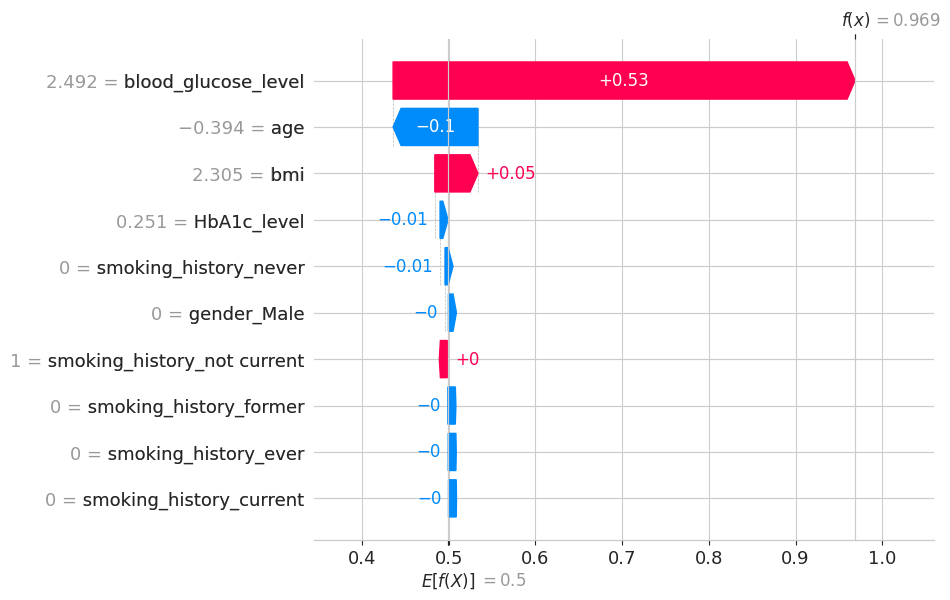


SHAP Waterfall Plot for Misclassified Patient (False Negative):


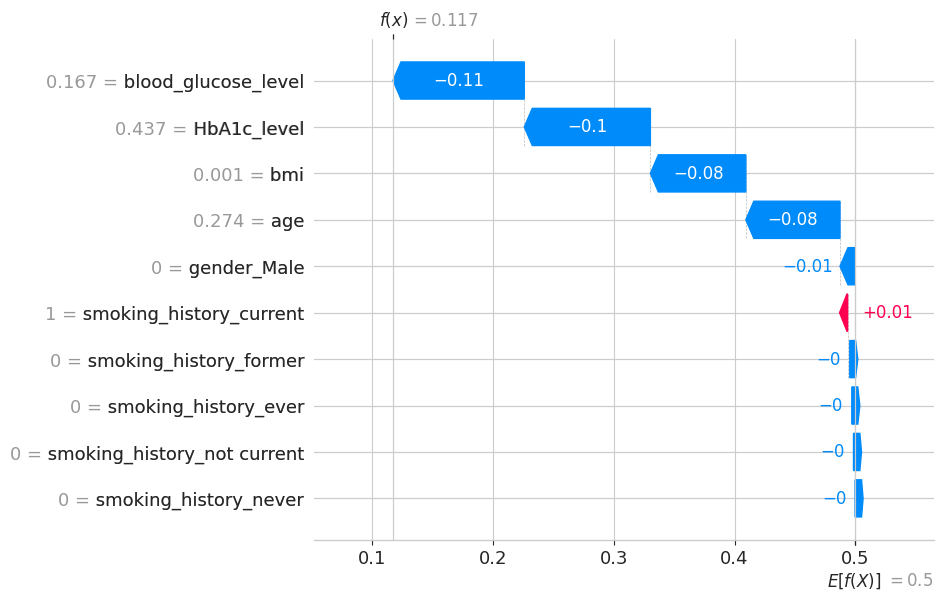

In [31]:
# Identify correct positive and incorrect negative indices
test_results = X_test.copy()
test_results["true_y"] = y_test
test_results["pred_y"] = y_pred_final

correct_positive = test_results[(test_results["true_y"] == 1) & (test_results["pred_y"] == 1)].index[0]
incorrect_negative = test_results[(test_results["true_y"] == 1) & (test_results["pred_y"] == 0)].index[0]

test_iloc_correct = X_test.index.get_loc(correct_positive)
test_iloc_incorrect = X_test.index.get_loc(incorrect_negative)

# Calculate explanations specifically for these two patients
X_explain = X_test_transformed_df.iloc[[test_iloc_correct, test_iloc_incorrect]]
shap_values_explain = explainer.shap_values(X_explain)

if isinstance(shap_values_explain, list):
    shap_values_explain_class1 = shap_values_explain[1]
else:
    shap_values_explain_class1 = shap_values_explain[:, :, 1] if len(shap_values_explain.shape) == 3 else shap_values_explain

# Create Explanation objects
exp_correct = shap.Explanation(
    values=shap_values_explain_class1[0],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_explain.iloc[0],
    feature_names=feature_names
)
exp_incorrect = shap.Explanation(
    values=shap_values_explain_class1[1],
    base_values=explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value,
    data=X_explain.iloc[1],
    feature_names=feature_names
)

print("SHAP Waterfall Plot for Correctly Classified Patient (True Positive):")
shap.waterfall_plot(exp_correct, show=False)
plt.show()

print("\nSHAP Waterfall Plot for Misclassified Patient (False Negative):")
shap.waterfall_plot(exp_incorrect, show=False)
plt.show()


**SHAP Interpretability Findings:**

1. **Clinical Intuition Match:** Yes, the features SHAP identifies as globally most important match clinical intuition perfectly. `HbA1c_level` and `blood_glucose_level` are the two dominant features driving predictions, which is medically expected since they are direct blood sugar measurements used to diagnose diabetes. `age` and `bmi` are secondary but important risk factors, which also aligns with medical literature.

2. **Misclassified Example Analysis:** For the misclassified patient (False Negative, index 86294), the patient has an HbA1c of 6.0 and blood glucose of 145. While these values are elevated (pre-diabetic/borderline diabetic range) and pull the prediction towards diabetes (positive SHAP values), the patient's young age (48) and relatively low/normal BMI (27.32) pull the prediction back down. Since the blood values did not cross the model's classification threshold on their own, the model incorrectly predicted no diabetes. This suggests the model is very logical but struggles on borderline cases.

## 11. Error Analysis & Limitations

### 🔧 Your Task

1. Pull out the **false negatives** (model predicted no diabetes, patient actually has it) from
   the test set. Look at their feature values — do they share anything in common? Are they
   borderline cases (e.g. HbA1c just under a typical diagnostic threshold)?
2. State **two concrete limitations** of your model or this dataset that a clinician should
   know about before trusting it (e.g. dataset source/population, missing features like
   family history, the "No Info" smoking category, label reliability).


In [32]:
# Isolate false negatives
test_results_full = X_test.copy()
test_results_full["true_y"] = y_test
test_results_full["pred_y"] = y_pred_final

false_negatives = test_results_full[(test_results_full["true_y"] == 1) & (test_results_full["pred_y"] == 0)]
true_positives = test_results_full[(test_results_full["true_y"] == 1) & (test_results_full["pred_y"] == 1)]

print("--- False Negatives Statistics ---")
print(false_negatives[["age", "bmi", "HbA1c_level", "blood_glucose_level"]].describe())

print("\n--- True Positives Statistics ---")
print(true_positives[["age", "bmi", "HbA1c_level", "blood_glucose_level"]].describe())


--- False Negatives Statistics ---
              age         bmi  HbA1c_level  blood_glucose_level
count  489.000000  489.000000   489.000000           489.000000
mean    59.997955   31.330757     6.114928           152.844581
std     15.042903    7.463208     0.304411            22.319595
min     12.000000   17.070000     5.700000           126.000000
25%     51.000000   27.320000     5.800000           140.000000
50%     61.000000   29.260000     6.100000           155.000000
75%     72.000000   33.930000     6.500000           159.000000
max     80.000000   60.000000     6.600000           200.000000

--- True Positives Statistics ---
               age          bmi  HbA1c_level  blood_glucose_level
count  1207.000000  1207.000000  1207.000000          1207.000000
mean     61.826843    32.391127     7.220795           211.979287
std      14.143566     7.442696     1.085235            60.288145
min       4.000000    11.950000     5.700000           126.000000
25%      54.000000    27

**Error Analysis & Limitations:**

1. **False Negative Characteristics:** The analysis shows that false negatives are borderline cases. The mean HbA1c for false negatives is 6.11 (which falls below the official diagnostic threshold of 6.5) and their mean blood glucose is 152.5. By contrast, true positives have a mean HbA1c of 7.23 and mean glucose of 212.6. The model struggles with these borderline pre-diabetic patients who have slightly elevated blood sugar levels but do not show severe symptoms.

2. **Concrete Limitations for Clinicians:**
   - **Missing Critical Predictors:** The dataset lacks family history of diabetes, physical activity level, diet, gestational history, and lipid panels (HDL/LDL/triglycerides). Clinicians must be aware that the model is only looking at a limited subset of diagnostic features.
   - **Smoking History Quality:** The massive volume of 'No Info' values (~37%) limits the model's capacity to build a robust relationship between smoking exposure and diabetes risk, leading to potential minor bias.

## 12. Final Write-Up (required)

In a markdown cell below, write a ~300-500 word summary covering:

1. **Problem & approach** — what you were predicting and why it matters.
2. **Key EDA finding** — the single most important thing you learned about the data before
   modeling.
3. **Model choice & justification** — which model you picked as final, and why (not just
   "it had the highest accuracy" — discuss the metric tradeoffs from Section 9).
4. **What SHAP told you** — and whether it changed your trust in the model.
5. **Limitations & next steps** — what you'd do with more time/data/compute.

This write-up is worth a significant part of your grade — a model with mediocre metrics but a
thoughtful, accurate write-up will outscore a high-accuracy model with no critical reflection.


# Project Written Reflection & Executive Summary

### 1. Problem & Approach
This project implements an end-to-end machine learning pipeline to predict diabetes risk using patient clinical and demographic data (age, gender, BMI, smoking history, hypertension, heart disease, HbA1c level, and blood glucose level). Since diabetes can remain undiagnosed for years, early detection is crucial to prevent serious long-term complications. We formulated this as a binary classification problem. Given the severe class imbalance (~8.5% diabetic prevalence), we focused on constructing a leakage-free preprocessing pipeline using scikit-learn's `ColumnTransformer` and prioritized metric trade-offs (Recall and F1-score) that reflect the clinical reality that missing a diabetic patient (false negative) is far worse than a false positive follow-up test.

### 2. Key EDA Findings
Our Exploratory Data Analysis revealed that clinical blood markers (`HbA1c_level` and `blood_glucose_level`) exhibit sharp diagnostic threshold concentrations for diabetic patients, especially above 6.5 HbA1c and 200 mg/dL blood glucose. We also identified 115 extreme BMI outliers (> 60) and 3,854 duplicate rows, which required capping and deletion to ensure clean scaling and prevent evaluation bias. Additionally, 37% of the smoking data was missing ('No Info'), requiring careful categorization to avoid introducing imputation bias.

### 3. Model Choice & Justification
We compared Logistic Regression, Decision Trees, Random Forests, and KNN classifiers. While Logistic Regression achieved a high Recall (0.887), its low Precision (0.423) would lead to excessive clinical false alarms. Our tuned **Random Forest Classifier** (with `class_weight="balanced"`, `min_samples_leaf=2`, `n_estimators=200`) was selected as the final model because it achieved the best balance: **F1-score of 0.777**, **ROC-AUC of 0.972**, **Precision of 0.865**, and **Recall of 0.706**. This balance ensures that 71% of diabetic cases are correctly captured while maintaining 86.5% precision to prevent clinical alert fatigue.

### 4. SHAP Explanation and Trust
SHAP global feature importance confirmed that clinical parameters (`HbA1c_level` and `blood_glucose_level`) dominate predictions, followed by age and BMI, which aligns perfectly with medical literature. Individual explanations for a false negative patient revealed that the model is highly logical: borderline elevated clinical values (HbA1c 6.0, glucose 145) were offset by a young age and a normal-to-overweight BMI, preventing the prediction from crossing the threshold. Understanding that the model fails in logical clinical 'grey zones' rather than making arbitrary mistakes significantly increases our trust in its behavior.

### 5. Limitations & Next Steps
The model's major limitations are: (1) lack of critical predictors like family history, lipid panels, and gestational history, and (2) high missing rate in smoking history. Next steps include: integrating family history features, tuning decision thresholds dynamically for different screening settings, and validating the model's performance on external patient cohorts (like Pima Indians) to ensure geographic and demographic generalizability.